<a href="https://colab.research.google.com/github/thomsmbockchildGod/colab-git-assignment2-TM/blob/main/Assignment7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error,r2_score

In [10]:
from sklearn.datasets import load_boston

ImportError: 
`load_boston` has been removed from scikit-learn since version 1.2.

The Boston housing prices dataset has an ethical problem: as
investigated in [1], the authors of this dataset engineered a
non-invertible variable "B" assuming that racial self-segregation had a
positive impact on house prices [2]. Furthermore the goal of the
research that led to the creation of this dataset was to study the
impact of air quality but it did not give adequate demonstration of the
validity of this assumption.

The scikit-learn maintainers therefore strongly discourage the use of
this dataset unless the purpose of the code is to study and educate
about ethical issues in data science and machine learning.

In this special case, you can fetch the dataset from the original
source::

    import pandas as pd
    import numpy as np

    data_url = "http://lib.stat.cmu.edu/datasets/boston"
    raw_df = pd.read_csv(data_url, sep="\s+", skiprows=22, header=None)
    data = np.hstack([raw_df.values[:

In [11]:
data_url = "http://lib.stat.cmu.edu/datasets/boston"
raw_df = pd.read_csv(data_url, sep="\s+", skiprows=22, header=None)
data = np.hstack([raw_df.values[::2, :], raw_df.values[1::2, :2]])
target = raw_df.values[1::2, 2]

<>:2: SyntaxWarning: invalid escape sequence '\s'
<>:2: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_10830/16828617.py:2: SyntaxWarning: invalid escape sequence '\s'
  raw_df = pd.read_csv(data_url, sep="\s+", skiprows=22, header=None)


In [12]:
columns = ["CRIM", "ZN", "INDUS", "CHAS", "NOX", "RM",
    "AGE", "DIS", "RAD", "TAX", "PTRATIO", "B", "LSTAT"]
df = pd.DataFrame(data, columns=columns)
df["MEDV"] = target

In [15]:
#Display the first few rows of the dataset to understand its structure.
print(df.head())

      CRIM    ZN  INDUS  CHAS    NOX  ...    TAX  PTRATIO       B  LSTAT  MEDV
0  0.00632  18.0   2.31   0.0  0.538  ...  296.0     15.3  396.90   4.98  24.0
1  0.02731   0.0   7.07   0.0  0.469  ...  242.0     17.8  396.90   9.14  21.6
2  0.02729   0.0   7.07   0.0  0.469  ...  242.0     17.8  392.83   4.03  34.7
3  0.03237   0.0   2.18   0.0  0.458  ...  222.0     18.7  394.63   2.94  33.4
4  0.06905   0.0   2.18   0.0  0.458  ...  222.0     18.7  396.90   5.33  36.2

[5 rows x 14 columns]


Identify which is continuous and categorical if applicable.
Categorical variables are : CHAS,RAD therefore there is no need to normalize them
Continuous variables are the rest a part of those mentioned above

In [16]:
scaler=StandardScaler()
df['MEDV']=scaler.fit_transform(df[['MEDV']])
cols=["CRIM", "ZN", "INDUS", "NOX", "RM",
    "AGE", "DIS", "TAX", "PTRATIO", "B", "LSTAT"]
df[cols]=scaler.fit_transform(df[cols])
df

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,-0.419782,0.284830,-1.287909,0.0,-0.144217,0.413672,-0.120013,0.140214,1.0,-0.666608,-1.459000,0.441052,-1.075562,0.159686
1,-0.417339,-0.487722,-0.593381,0.0,-0.740262,0.194274,0.367166,0.557160,2.0,-0.987329,-0.303094,0.441052,-0.492439,-0.101524
2,-0.417342,-0.487722,-0.593381,0.0,-0.740262,1.282714,-0.265812,0.557160,2.0,-0.987329,-0.303094,0.396427,-1.208727,1.324247
3,-0.416750,-0.487722,-1.306878,0.0,-0.835284,1.016303,-0.809889,1.077737,3.0,-1.106115,0.113032,0.416163,-1.361517,1.182758
4,-0.412482,-0.487722,-1.306878,0.0,-0.835284,1.228577,-0.511180,1.077737,3.0,-1.106115,0.113032,0.441052,-1.026501,1.487503
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
501,-0.413229,-0.487722,0.115738,0.0,0.158124,0.439316,0.018673,-0.625796,1.0,-0.803212,1.176466,0.387217,-0.418147,-0.014454
502,-0.415249,-0.487722,0.115738,0.0,0.158124,-0.234548,0.288933,-0.716639,1.0,-0.803212,1.176466,0.441052,-0.500850,-0.210362
503,-0.413447,-0.487722,0.115738,0.0,0.158124,0.984960,0.797449,-0.773684,1.0,-0.803212,1.176466,0.441052,-0.983048,0.148802
504,-0.407764,-0.487722,0.115738,0.0,0.158124,0.725672,0.736996,-0.668437,1.0,-0.803212,1.176466,0.403225,-0.865302,-0.057989


In [17]:
#EDA and Data Preprocessing:

#Check for missing/null values.

print(df.isnull().sum())

CRIM       0
ZN         0
INDUS      0
CHAS       0
NOX        0
RM         0
AGE        0
DIS        0
RAD        0
TAX        0
PTRATIO    0
B          0
LSTAT      0
MEDV       0
dtype: int64


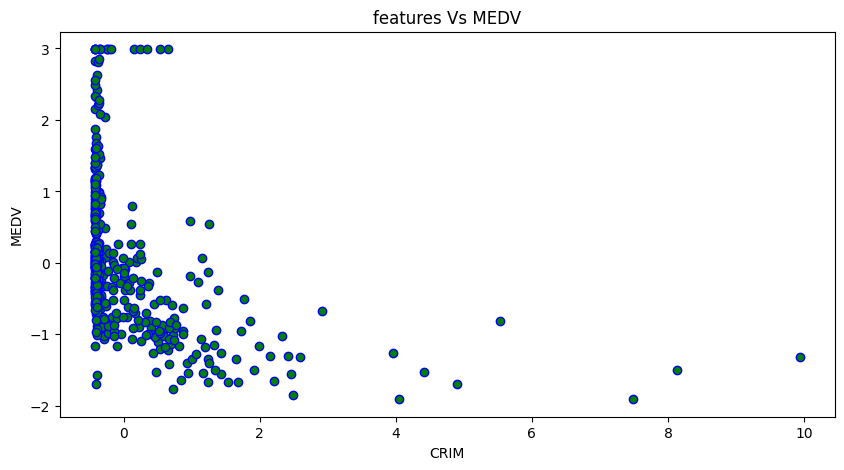

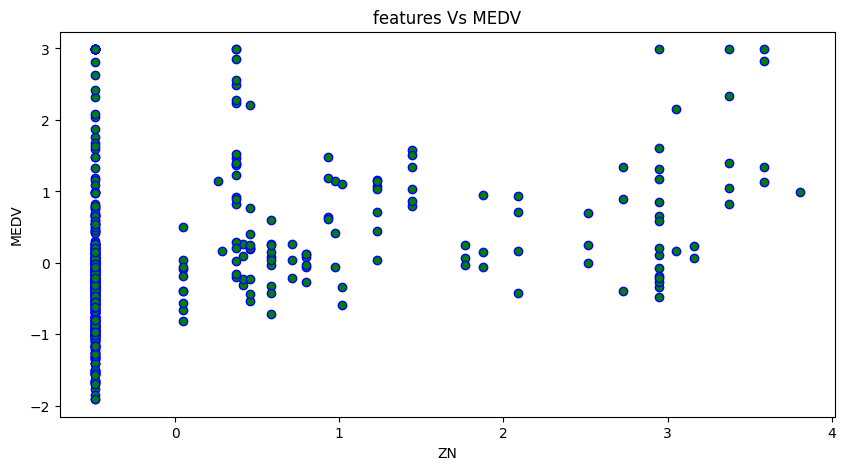

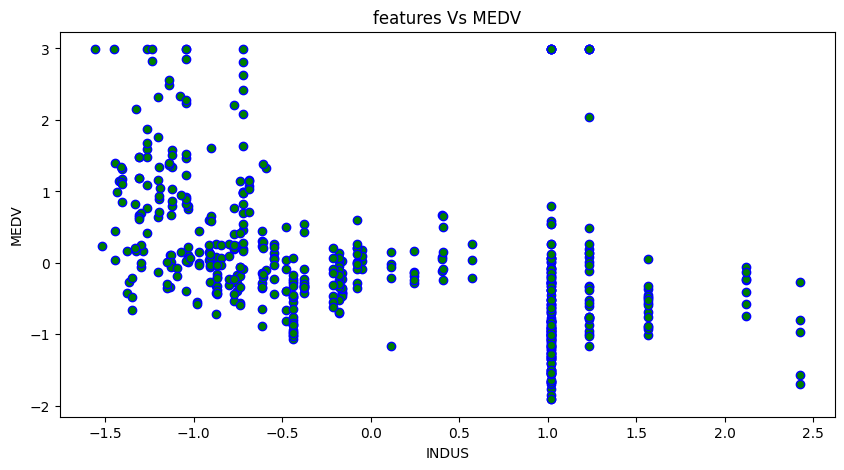

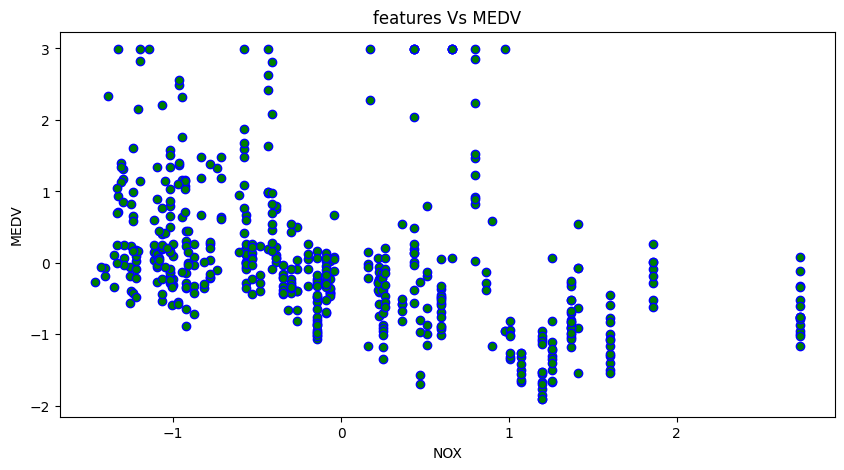

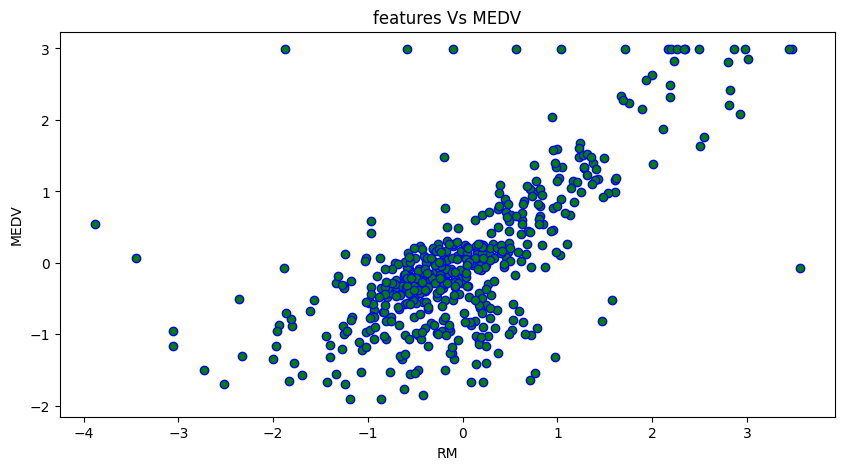

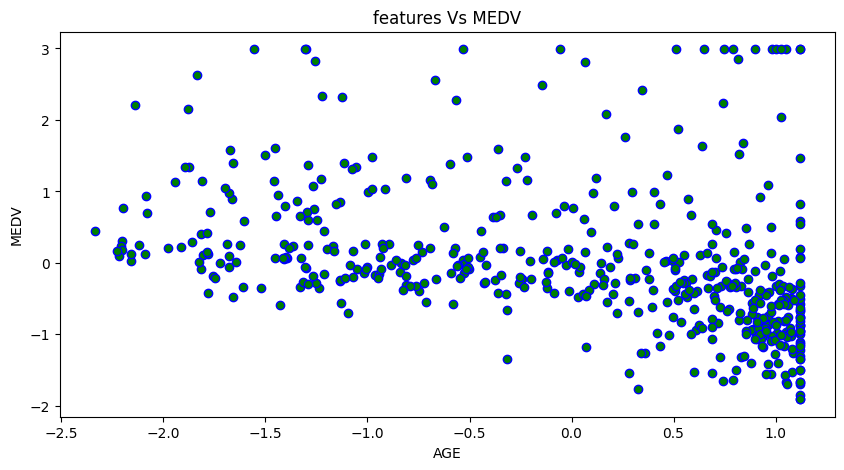

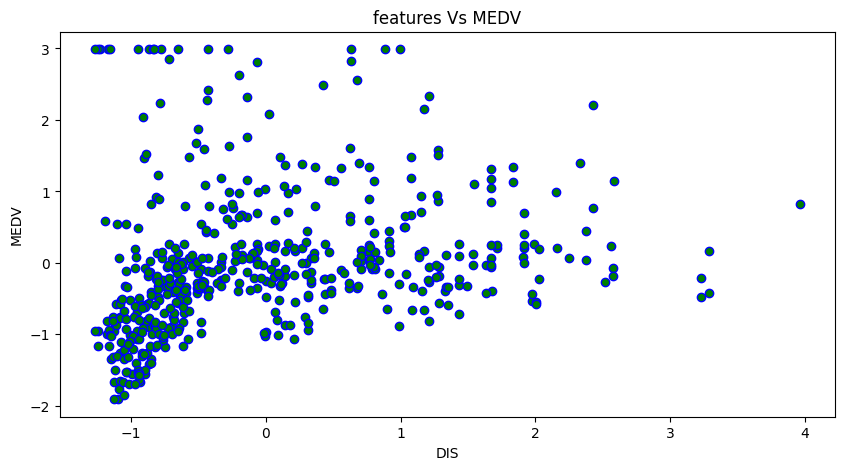

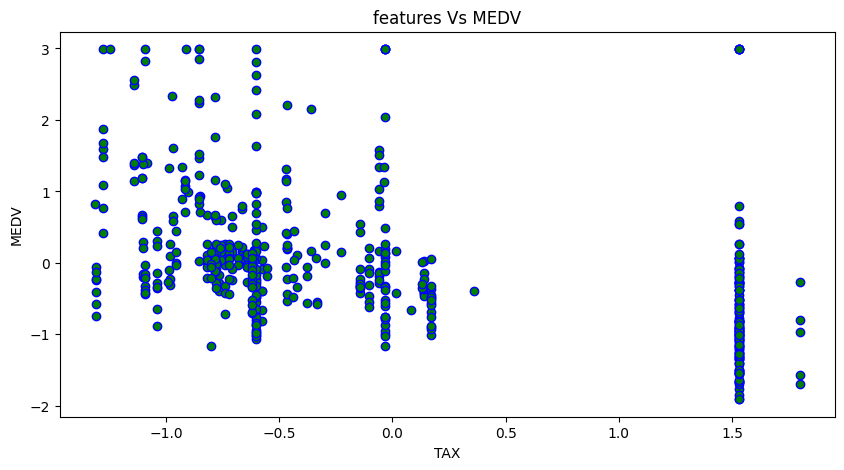

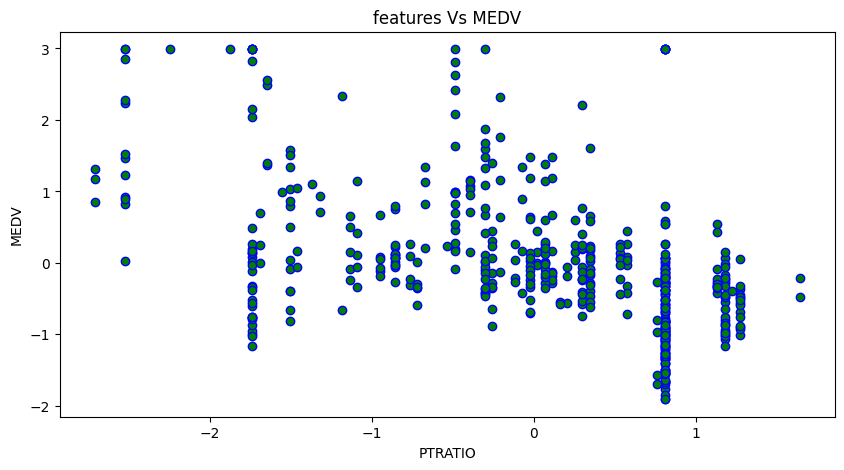

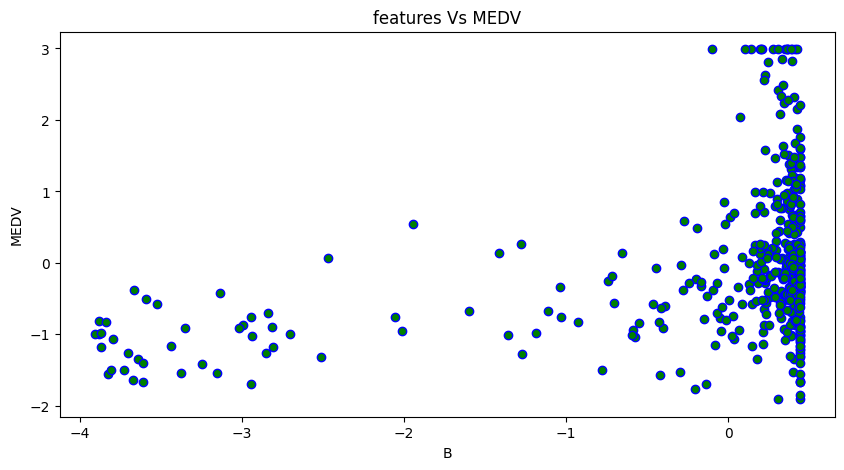

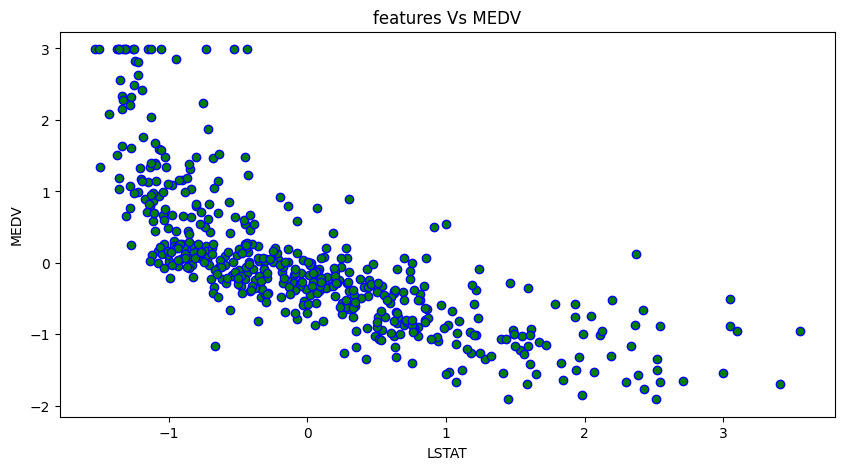

In [23]:
#Create a function to automate scatter plots for all features vs the target variable.
#Use the function to visualize the relationships between multiple features and the target variable.
def scatter_plot(features):
  plt.figure(figsize=(10,5))
  plt.scatter(df[features],df['MEDV'],color='green',edgecolors='blue')
  plt.title('features Vs MEDV')
  plt.xlabel(features)
  plt.ylabel('MEDV')
  plt.show()

scatter_plot('CRIM')
scatter_plot('ZN')
scatter_plot('INDUS')
scatter_plot('NOX')
scatter_plot('RM')
scatter_plot('AGE')
scatter_plot('DIS')
scatter_plot('TAX')
scatter_plot('PTRATIO')
scatter_plot('B')
scatter_plot('LSTAT')
#

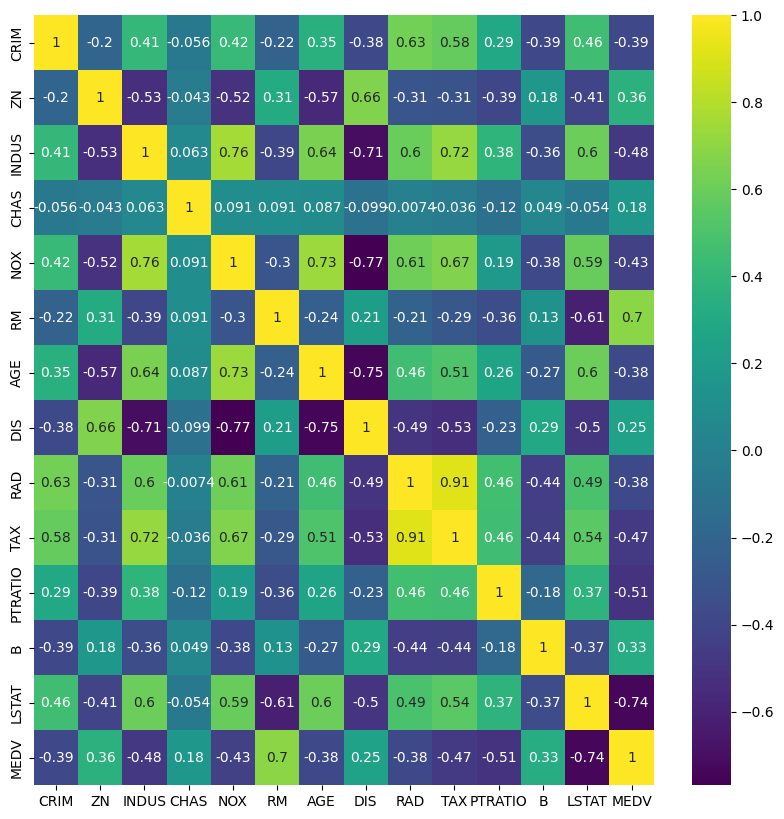

In [27]:
correlation_matrix=df.corr()
plt.figure(figsize=(10,10))
sns.heatmap(correlation_matrix,annot=True,cmap='viridis')
plt.show()

In [28]:
#ML Model Training:

#Split the dataset into training and testing sets.
X=df.drop(columns=['MEDV'])
Y=df['MEDV']
x_train,x_test,y_train,y_test=train_test_split(X,Y,test_size=0.3,random_state=42)

#Choose an appropriate regression model: Decision Tree or Random Forest.

model=DecisionTreeRegressor()

#Train the model on the training data.
model.fit(x_train,y_train)

#model prediction

y_pred=model.predict(x_test)

#Evaluate the model's performance using appropriate metrics.
mse=mean_squared_error(y_test,y_pred)
rmse=np.sqrt(mse)
r2=r2_score(y_test,y_pred)
print(f'Mean Squared Error: {mse}')
print(f'Root Mean Squared Error: {rmse}')
print(f'R-squared: {r2}')

Mean Squared Error: 0.11947842714092541
Root Mean Squared Error: 0.34565651612681253
R-squared: 0.8646370049102711


R-squared of 86% indicate that Decision Tree model predicted well the output variable with less errors (14%)

In [31]:
#Predict house prices from a new set of feature inputs.

#features=["CRIM", "ZN", "INDUS", "CHAS", "NOX", "RM",
    #"AGE", "DIS", "RAD", "TAX", "PTRATIO", "B", "LSTAT"]

features=[25.50,70,50.25,1,80,6.5,25,30.50,7,350.00,60.25,296.70,5.5]

predict_medv=model.predict([features])

predict_medv

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeRegressor was fitted with feature names
  warnings.warn(


array([-0.06887304])